In [1]:
#Instalamos la librerias necesarias (solo la primera vez que ejecutamos el script)
!pip install -r requirements.txt


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.impute import KNNImputer
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import shap
import lightgbm as lgb
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from scipy import stats
from sklearn.preprocessing import OrdinalEncoder
from statsmodels.tools.tools import add_constant

# **0. CONTEXTO Y CARGA DATOS**

In [3]:
df=pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=927&path=AB_NYC_2019.csv")
df.rename(columns={"availability_365": "days_available", "calculated_host_listings_count": "lodging"}, inplace=True)
df.set_index("id",inplace=True)
df.head(5)

,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,lodging,days_available
id,,,,,,,,,,,,,,,
2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


# **1. CRIBADO MANUAL**

## 1.1. Verificar valores

### 1.1.1. Unicos

In [4]:
#Valores unicos por cada columna
unicos=df.nunique()
print("No hay columnas con valores únicos" if sum(unicos==1)==0 else "Hay columnas con valores únicos")

No hay columnas con valores únicos


### 1.1.2. Eliminación de filas y columnas duplicadas

In [5]:
#Indice
dup_fil=df.duplicated().sum()
print("No hay filas duplicadas" if dup_fil==0 else "Hay filas duplicadas")

No hay filas duplicadas


In [6]:
#Trasponemos las columnas para verificar que toda la fila (variable) no sea igual a otra
dup_col=df.T.duplicated(keep=False).sum()
print("No hay variables exactamente iguales" if dup_col==0 else "Hay variables exactamente iguales")

No hay variables exactamente iguales


### 1.1.3. Eliminación de variables redundantes

#### A) Identificadores por anfitrión

In [7]:
#Calculamos el numero de valores unicos por host_id: si solo hay 1, las variables son redundantes
host_name_por_id = df.groupby('host_id')['host_name'].nunique()
print("host_id con >1 host_name:", (host_name_por_id > 1).sum())

host_id con >1 host_name: 0


[]

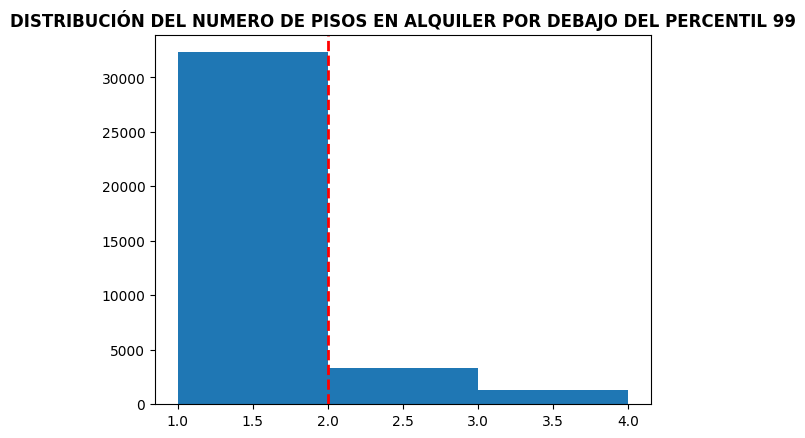

In [8]:
pisos=df["host_id"].value_counts()
plt.hist(pisos[pisos<pisos.quantile(0.99)].astype("int"), bins="auto") #Nº de anuncios por debajo del percentil
plt.axvline(2, color='red', linestyle='--', linewidth=2)
plt.title("Distribución del numero de pisos en alquiler por debajo del percentil 99".upper(), fontweight="bold")
plt.plot()

A partir del indice, vamos a crear una variables que cuantifique si un individuo ofertante es profesional (n>2)

In [9]:
#Hoster profesional
prof=df['host_id'].map(lambda x: 1 if pisos.get(x, 0) >= 2 else 0)
posicion = df.columns.get_loc('host_id')
df.insert(posicion+1, 'host_prof', prof)
df.head(2)

,name,host_id,host_prof,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,lodging,days_available
id,,,,,,,,,,,,,,,,
2539,Clean & quiet apt home by the park,2787,1,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
2595,Skylit Midtown Castle,2845,1,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355


#### B) Identificadores por alojamiento

In [10]:
name_por_id = df.groupby('id')['name'].nunique()
print("id con >1 name:", (name_por_id > 1).sum())

id con >1 name: 0


In [11]:
aloj=df.index.value_counts().sum()
print("No hay alojamientos que aparecen más de una vez" if aloj==df.shape[0] else "Hay alojamientos duplicadas")

No hay alojamientos que aparecen más de una vez


In [12]:
#Eliminamos columnas innecesarias
df.drop(columns=["host_name", "host_id","name"], axis=1, inplace=True)

## 1.3. Verificar missing values

In [13]:
# Columnas columnas con más de un 15% de valores faltantes
missing=df.isna().mean()*100
missing[missing>15]

last_review          20.558339
reviews_per_month    20.558339
dtype: float64

<Axes: >

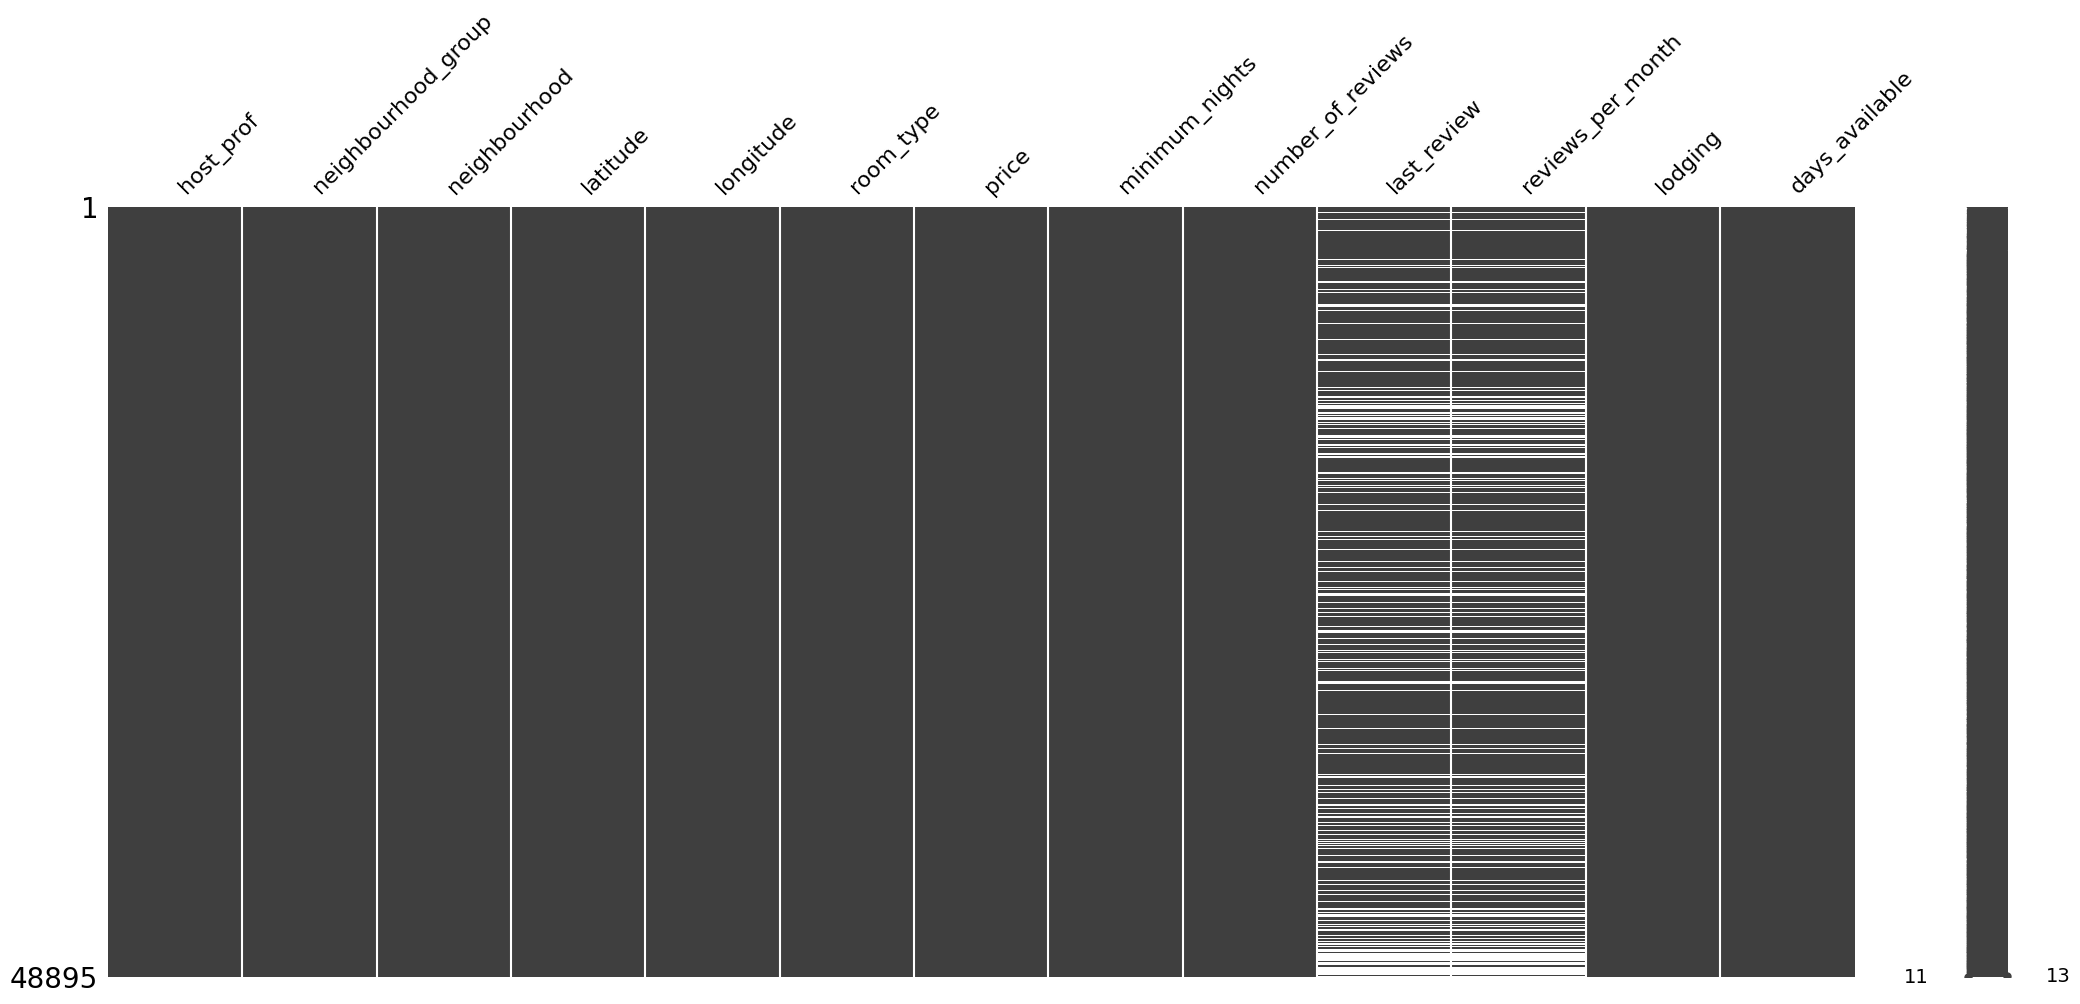

In [14]:
# Gráficamente
msno.matrix(df)

Eliminaremos una fila o columna si presenta más de un 40% de sus datos como faltantes.

In [15]:
#Verificamos si hay columnas con más de un 40% de missing values
column=df.isna().sum()/len(df)*100
print("No hay columnas con muchas variables sin valores" if column[column>40].sum()==0 
      else f"Las columnas {column[column>40].index.to_list()} no aportan información")

No hay columnas con muchas variables sin valores


In [16]:
#Verificamos si hay filas con más de un 40% de missing values
filas=df.T.isna().sum()/len(df.T)*100
print("No hay filas con muchas variables sin valores" if filas[filas>40].sum()==0 
      else f"Hay {filas.sum()} filas con variables sin valores")

No hay filas con muchas variables sin valores


In [17]:
#Mostramos las filas para analizar algun patrón
df[["number_of_reviews", "last_review", "reviews_per_month"]][df["last_review"].isna()]

,number_of_reviews,last_review,reviews_per_month
id,,,
3647,0,NaN,NaN
7750,0,NaN,NaN
8700,0,NaN,NaN
11452,0,NaN,NaN
11943,0,NaN,NaN
...,...,...,...
36484665,0,NaN,NaN
36485057,0,NaN,NaN
36485431,0,NaN,NaN


Podemos observar que los valores faltantes en las columnas ``last_review`` y  ``reviews_per_month`` se debe a que dicho apartamento no posee reseñas. De esta forma:

- Tendremos que imputar a ``reviews_per_month`` el valor 0 
- Mientras que para ``last_review`` no podríamos hacer nada.

## 1.4. Codificar variables categoricas

Como tenemos 3 variables de localización greográfica (``Latitude/Longitude``, ``neighbourhood``, ``neighbourhood_group``) nos quedaremos con la más general (``neighbourhood_group``) y específica (``Latitude/Longitude``).

In [18]:
df.drop(columns="neighbourhood", axis=1, inplace=True)

In [19]:
df.select_dtypes("object")

,neighbourhood_group,room_type,last_review
id,,,
2539,Brooklyn,Private room,2018-10-19
2595,Manhattan,Entire home/apt,2019-05-21
3647,Manhattan,Private room,NaN
3831,Brooklyn,Entire home/apt,2019-07-05
5022,Manhattan,Entire home/apt,2018-11-19
...,...,...,...
36484665,Brooklyn,Private room,NaN
36485057,Brooklyn,Private room,NaN
36485431,Manhattan,Entire home/apt,NaN


De esta forma, vamos a categorizar:

- ``neighbourhood_group``, que es nominal (no hay un orden implicito en las categorias), por lo que aproximaremos ese orden a través de la técnica *Oredered Target Encoding*. 

- ``room_type``, que sí es ordinal y en la que aplicaremos *Ordinal Encoding*


### 1.4.1. Neighbourhood_group

In [20]:
# Categorías
df["neighbourhood_group"].value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

#### A) Test diferenica medias

In [21]:
## Diccionario con el precio por categorias
prec_barr={}

for barr in df["neighbourhood_group"].unique():
    prec_barr[barr]=df["price"][df["neighbourhood_group"]==barr].to_list()

Tipo de test de diferencias de medias:

- ANOVA (Var. normales y homocedasticas)

- Alexander govern (Var heterocedasticas)

- Kruskal (Var. no normales)

In [22]:
# Test de normalidad con KOLMOGOROV CON KOLMOGOROV-SMIRNOV
for barrio, precios in prec_barr.items():
    # Calcular media y desviación estándar del grupo
    media = np.mean(precios)
    desv_std = np.std(precios)
    
    # Realizar el test de Kolmogorov-Smirnov
    ''' 
    H0: La muestra sigue la distribución especificada (Normal)
    H1: La muestra no sigue la distribución
    '''
    estadistico, p_valor = stats.kstest(precios, 'norm', args=(media, desv_std))
    
    print(f"\n{barrio}:")
    print(f"  • Tamaño muestra: {len(precios)}")
    print(f"  • Estadístico K-S: {estadistico:.4f}")
    print(f"  • P-valor: {p_valor:.4f}")
    
    # Interpretación
    if p_valor < 0.05:
        print(f" NO sigue distribución normal (p < 0.05)")
    else:
        print(f" Puede considerarse normal (p >= 0.05)")


Brooklyn:
  • Tamaño muestra: 20104
  • Estadístico K-S: 0.2963
  • P-valor: 0.0000
 NO sigue distribución normal (p < 0.05)

Manhattan:
  • Tamaño muestra: 21661
  • Estadístico K-S: 0.2841
  • P-valor: 0.0000
 NO sigue distribución normal (p < 0.05)

Queens:
  • Tamaño muestra: 5666
  • Estadístico K-S: 0.3242
  • P-valor: 0.0000
 NO sigue distribución normal (p < 0.05)

Staten Island:
  • Tamaño muestra: 373
  • Estadístico K-S: 0.3635
  • P-valor: 0.0000
 NO sigue distribución normal (p < 0.05)

Bronx:
  • Tamaño muestra: 1091
  • Estadístico K-S: 0.2661
  • P-valor: 0.0000
 NO sigue distribución normal (p < 0.05)


In [23]:
''' 
Test diferencias de medias de variables no normales Kruskal-Wallis
    H0: No hay diferenicas signficativas de precio medio por cada categoría
    H1: Existe al menos una categoría con un precio medio distinto
'''

#Realizamos el test
estadistico,p_valor= stats.kruskal(prec_barr["Manhattan"], prec_barr["Brooklyn"], prec_barr["Queens"], prec_barr["Bronx"], prec_barr["Staten Island"])
print( "RESULTADOS:")
print(f"  • Estadístico K-W: {estadistico:.4f}")
print(f"  • P-valor: {p_valor:.4f}\n")

# Interpretación
print( "CONCLUSION:")
if p_valor < 0.05:
    print(f" • Existen diferencias en el precio medio")
else:
    print(f" • No existen diferencias en el precio medio")

RESULTADOS:
  • Estadístico K-W: 7027.2408
  • P-valor: 0.0000

CONCLUSION:
 • Existen diferencias en el precio medio


#### B) Ordered Target Encoding

Para evitar el *data leakage* los valores promedio de ``y`` que utilizaremos para dar orden a las categorías de ``job`` deben ser extraidos de train y copiados a test. Esto hace que test sea lo más imparcial posible.

### 1.4.2. Room_type

[]

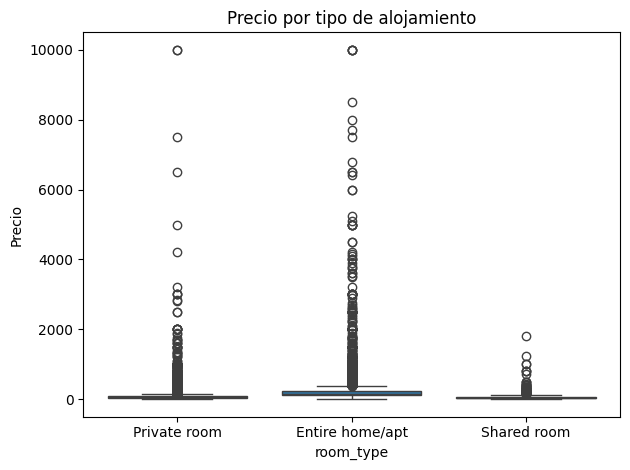

In [24]:
## Representacion
sns.boxplot(data=df, x="room_type", y="price")
plt.title("Precio por tipo de alojamiento")
plt.ylabel("Precio")
plt.tight_layout()
plt.plot()

In [25]:
# Definimos el orden lógico (de menor a mayor)
df["room_type"].map({})
orden_logico = ['Shared room', 'Private room', 'Entire home/apt']
# Instanciamos la funcion
ordenc = OrdinalEncoder(categories=[orden_logico], dtype=int, handle_unknown='use_encoded_value', unknown_value=-1)

# Transformamos
df["room_type"] = ordenc.fit_transform(df[["room_type"]])
df["room_type"].value_counts().sort_index()

room_type
0     1160
1    22326
2    25409
Name: count, dtype: int64

## 1.5. Extracción de características

### A) Dias desde la última reseña

In [26]:
# Pasamos la columna a datetime para poder trabajar con ella 
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce') #errors --> maneja valores no YY/MM/dd
# Creamos la fecha de la utima reseña posible
## Establecemos como ultima fecha 2 dias de margen sobre la fecha mas cercana
today = df['last_review'].sort_values(ascending=False).iloc[0]+ pd.Timedelta(days=2)
df['days_since_review'] = (today - df['last_review']).dt.days
#Eliminamos la columna fecha
df.drop(columns=["last_review"], axis=1, inplace=True)
df['days_since_review']

id
2539        264.0
2595         50.0
3647          NaN
3831          5.0
5022        233.0
            ...  
36484665      NaN
36485057      NaN
36485431      NaN
36485609      NaN
36487245      NaN
Name: days_since_review, Length: 48895, dtype: float64

In [27]:
#Reseñas al mes iguales a 0
df['reviews_per_month'] = pd.to_numeric(df['reviews_per_month'], errors='coerce')
df['reviews_per_month'].fillna(0, inplace=True)
df[df['reviews_per_month'].isna()]

C:\Users\jjime\AppData\Local\Temp\ipykernel_10996\3103072898.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews_per_month'].fillna(0, inplace=True)


,host_prof,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,lodging,days_available,days_since_review
id,,,,,,,,,,,,


## 1.6. División Train-Test

In [28]:
X = df.drop('price',axis=1)
y = df['price']
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42) #random_state establece una semilla para que la division aleatoria sea la misma
X_train.head()

,host_prof,neighbourhood_group,latitude,longitude,room_type,minimum_nights,number_of_reviews,reviews_per_month,lodging,days_available,days_since_review
id,,,,,,,,,,,
25674366,0,Brooklyn,40.71577,-73.95530,2,3,11,0.87,1,1,55.0
19100971,0,Manhattan,40.84917,-73.94048,1,2,2,0.16,1,0,380.0
24209867,1,Brooklyn,40.68993,-73.95947,1,2,0,0.00,2,0,NaN
22451798,0,Brooklyn,40.68427,-73.93118,2,3,87,4.91,1,267,5.0
5344850,0,Queens,40.74705,-73.89564,1,5,13,0.25,1,0,204.0


### 1.6.1. Target Encoding

In [29]:
#Crosstab con precio medio de cada barrio
var_ana=pd.merge(X_train["neighbourhood_group"], y_train, on=y_train.index)
var_ana.groupby("neighbourhood_group")["price"].agg(['count', 'sum', 'mean']).sort_values(by="mean", ascending=False)

,count,sum,mean
neighbourhood_group,,,
Manhattan,17380,3451819,198.608688
Brooklyn,16096,2006052,124.630467
Staten Island,294,34115,116.037415
Queens,4482,445170,99.323963
Bronx,864,76991,89.109954


In [30]:
# Definimos el orden haciendo uso del orden anterior
orden_inducido = ["Bronx", "Queens", "Staten Island", "Brooklyn", "Manhattan"]
# Instanciamos la funcion
ordenc = OrdinalEncoder(categories=[orden_inducido], dtype=int, handle_unknown='use_encoded_value', unknown_value=-1)

# Transformamos train
X_train["neighbourhood_group"] = ordenc.fit_transform(X_train[["neighbourhood_group"]])
print(X_train["neighbourhood_group"].unique())
print("="*35)

#Transformamos test
X_test["neighbourhood_group"] = ordenc.fit_transform(X_test[["neighbourhood_group"]])
print(X_test["neighbourhood_group"].unique())

[3 4 1 0 2]
[3 1 4 0 2]


## 1.8. Imputación de missing values

En caso de tener que imputar missing values al azar, podemos realizar el siguiente análisis

In [31]:
''' Primero, bucariamos las variables que presentan una mayor correlación a la variable con missings
df.corr()["days_since_review"]'''

' Primero, bucariamos las variables que presentan una mayor correlación a la variable con missings\ndf.corr()["days_since_review"]'

In [32]:
''' Segundo, desarrollamos un modelo KNN Imputer para imputar missings como media de las n filas con características más parecidas

impute_knn=KNNImputer(n_neighbors=2)

df_imp=impute_knn.fit_transform(df[["host_prof", "number_of_reviews", "days_since_review"]]) #seleccionamos las dos variables más correlacionadas

df_imp=pd.DataFrame(df_imp, columns=["host_prof", "number_of_reviews", "days_since_review"])

df_imp["days_since_review"].isnull().sum() '''

' Segundo, desarrollamos un modelo KNN Imputer para imputar missings como media de las n filas con características más parecidas\n\nimpute_knn=KNNImputer(n_neighbors=2)\n\ndf_imp=impute_knn.fit_transform(df[["host_prof", "number_of_reviews", "days_since_review"]]) #seleccionamos las dos variables más correlacionadas\n\ndf_imp=pd.DataFrame(df_imp, columns=["host_prof", "number_of_reviews", "days_since_review"])\n\ndf_imp["days_since_review"].isnull().sum() '

Otros métodos:

- Miss Forest (En lugar de poner un parche simple (como la media), MissForest aprende las relaciones entre tus datos para deducir qué pieza falta)

- IterativeImpute (Usan el resto de variables para predecir el valor faltante mediante regresiones iterativas)

## 1.9. Análisis de valores Outliers

In [33]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
host_prof,39116.0,0.339554,0.473564,0.00000,0.000000,0.000000,1.000000,1.00000
neighbourhood_group,39116.0,3.141374,1.043551,0.00000,3.000000,3.000000,4.000000,4.00000
latitude,39116.0,40.728927,0.054555,40.49979,40.690067,40.723035,40.763180,40.91306
longitude,39116.0,-73.952311,0.046029,-74.24285,-73.983080,-73.955750,-73.936498,-73.71299
room_type,39116.0,1.497520,0.544968,0.00000,1.000000,2.000000,2.000000,2.00000
minimum_nights,39116.0,7.144775,21.472973,1.00000,1.000000,3.000000,5.000000,1250.00000
number_of_reviews,39116.0,23.334978,44.499352,0.00000,1.000000,5.000000,24.000000,629.00000
reviews_per_month,39116.0,1.094376,1.604249,0.00000,0.040000,0.370000,1.590000,58.50000
lodging,39116.0,7.188925,33.172629,1.00000,1.000000,1.000000,2.000000,327.00000
days_available,39116.0,113.445368,131.846430,0.00000,0.000000,46.000000,229.000000,365.00000


### A) Valores riesgo de outliers

#### Rango intercuantilico

In [34]:
''' Rango intercuantilico
ric=X_train["minimum_nights"].quantile(0.75)-X_train["minimum_nights"].quantile(0.25)
lim_inf=X_train["minimum_nights"].quantile(0.25)-1.5*ric
lim_sup=X_train["minimum_nights"].quantile(0.25)-1.5*ric'''

' Rango intercuantilico\nric=X_train["minimum_nights"].quantile(0.75)-X_train["minimum_nights"].quantile(0.25)\nlim_inf=X_train["minimum_nights"].quantile(0.25)-1.5*ric\nlim_sup=X_train["minimum_nights"].quantile(0.25)-1.5*ric'

#### Isolation Forest

In [35]:
iso = IsolationForest(random_state=123)
df_num = X_train.copy()
df_num['outlier_flag'] = iso.fit_predict(X_train)

In [36]:
df_num['outlier_flag'].value_counts(normalize=True)*100

outlier_flag
 1    82.817773
-1    17.182227
Name: proportion, dtype: float64

In [37]:
df_num[df_num['outlier_flag']==1].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
host_prof,32395.0,0.27,0.44,0.00,0.00,0.00,1.00,1.00
neighbourhood_group,32395.0,3.32,0.82,0.00,3.00,3.00,4.00,4.00
latitude,32395.0,40.73,0.05,40.57,40.69,40.72,40.76,40.88
longitude,32395.0,-73.96,0.03,-74.09,-73.98,-73.96,-73.94,-73.73
room_type,32395.0,1.53,0.51,0.00,1.00,2.00,2.00,2.00
minimum_nights,32395.0,5.23,8.24,1.00,2.00,3.00,5.00,120.00
number_of_reviews,32395.0,17.49,29.86,0.00,1.00,5.00,19.00,243.00
reviews_per_month,32395.0,0.90,1.25,0.00,0.04,0.32,1.27,10.54
lodging,32395.0,2.22,4.78,1.00,1.00,1.00,2.00,65.00
days_available,32395.0,94.02,123.22,0.00,0.00,19.00,177.00,365.00


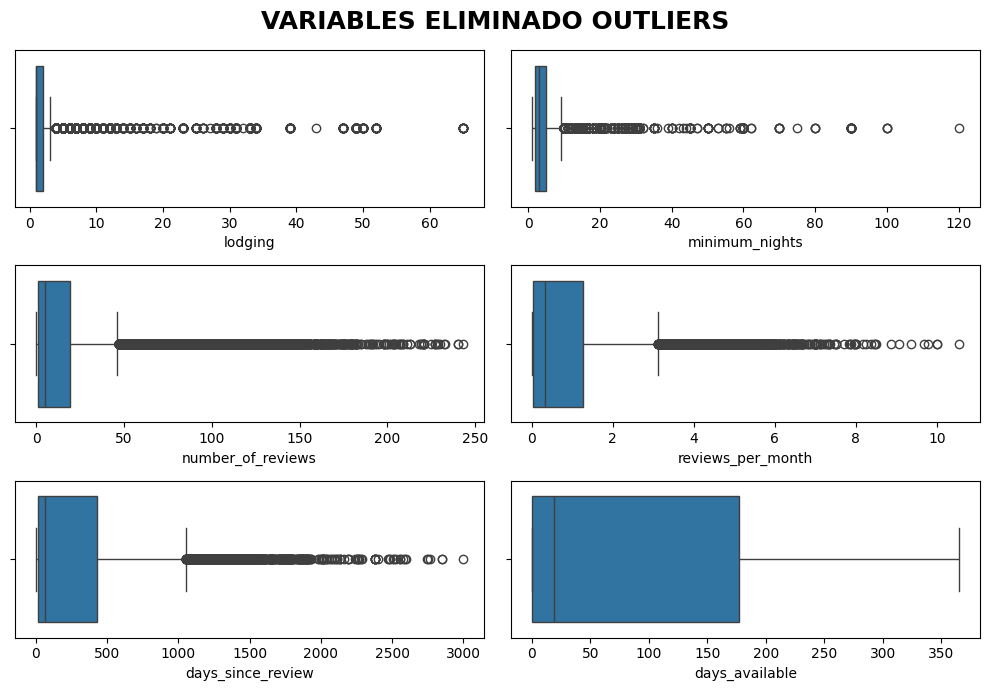

In [38]:
fig, axis = plt.subplots(3, 2, figsize = (10, 7))

df_analisis=df_num[df_num['outlier_flag']==1]
# Crear una figura múltiple con histogramas y diagramas de caja
sns.boxplot(ax = axis[0, 0], data = df_analisis, x = "lodging")
sns.boxplot(ax = axis[0, 1],data = df_analisis, x = "minimum_nights")
sns.boxplot(ax = axis[1, 0],data = df_analisis, x = "number_of_reviews")
sns.boxplot(ax = axis[1, 1],data = df_analisis, x = "reviews_per_month")
sns.boxplot(ax = axis[2, 0],data = df_analisis, x = "days_since_review")
sns.boxplot(ax = axis[2, 1],data = df_analisis, x = "days_available")
fig.suptitle("Variables eliminado outliers".upper(), size=18, fontweight="bold")
# Ajustar el layout
plt.tight_layout()
# Mostrar el plot
plt.show()

### B) Soluciones

- **Winsorización** (techo y suelo): Cortas dist. por un máximo (p99) y mínimo(p1)

- **Transformación Matemática**: logaritmica (para dist. positivas), Yeo-Johnson (para cualquier valor)

- **Escalamiento Robusto**: tenemos en cuenta la mediana para calcular la media.

- **Discretización**: creación de rangos de y

# **2. SELECCIÓN DE CARCATERÍSTICAS**

## 2.1. Aplicación de los métodos

### A) Feature importance con Random Forest

In [39]:
# Entrenamiento de RF
model = RandomForestRegressor(random_state=42,n_jobs=-1).fit(X_train, y_train)

In [40]:
# Importancia de características
importances = model.feature_importances_*100

# Convertir a DataFrame
df_rf = pd.DataFrame({'feature': X_train.columns,'rf_importance': importances}).sort_values(by='rf_importance', ascending=False)

# Calculamos la importancia acumulada
df_rf['rf_importance_acum'] = df_rf['rf_importance'].cumsum()
df_rf

,feature,rf_importance,rf_importance_acum
3,longitude,25.027879,25.027879
2,latitude,21.736263,46.764142
10,days_since_review,13.214814,59.978956
9,days_available,10.119010,70.097966
5,minimum_nights,8.674605,78.772570
4,room_type,6.154381,84.926951
8,lodging,5.883608,90.810559
7,reviews_per_month,3.875955,94.686514
6,number_of_reviews,3.471188,98.157701
1,neighbourhood_group,1.124472,99.282174


### B) Permutation/Shuffle importance con XGBRegressor 

In [41]:
# Para esta técnica y la de shap se necesita conjunto de validación
X_train1, X_val, y_train1, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Ajustamos el modelo
model_xgb = XGBRegressor(objective='reg:squarederror', random_state=42).fit(X_train1, y_train1)

In [42]:
# Realizamos 10 permutaciones por cada característica
perm = permutation_importance(model_xgb, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1, scoring='neg_mean_absolute_percentage_error')
df_perm = pd.DataFrame({'feature': X_train.columns, 'perm': perm.importances_mean*100}).sort_values('perm', ascending=False)
df_perm

,feature,perm
3,longitude,40.694110
7,reviews_per_month,38.053599
4,room_type,37.614902
10,days_since_review,31.782088
5,minimum_nights,16.453186
2,latitude,16.033156
8,lodging,15.791780
9,days_available,11.981469
1,neighbourhood_group,11.562212
6,number_of_reviews,10.191409


### C) SHAP

In [43]:
# Ajustamos el modelo
model_lgbm = lgb.LGBMRegressor(random_state=42, n_jobs=-1).fit(X_train1, y_train1)

explainer = shap.Explainer(model_lgbm, X_val)   # usa el mismo X_val
shap_vals = explainer(X_val, check_additivity=False).values

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002048 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1635
[LightGBM] [Info] Number of data points in the train set: 31292, number of used features: 11
[LightGBM] [Info] Start training from score 153.698581


 98%|===================| 7682/7824 [00:34<00:00]        

In [44]:
imp_shap = np.abs(shap_vals).mean(axis=0)
imp_shap_pct = imp_shap/imp_shap.sum()*100
df_shap = pd.DataFrame({"feature": X_val.columns, "shap": imp_shap_pct}).sort_values('shap', ascending=False)
df_shap

,feature,shap
4,room_type,27.909315
3,longitude,13.486182
9,days_available,12.984192
10,days_since_review,10.954370
5,minimum_nights,8.052878
2,latitude,7.768779
7,reviews_per_month,4.994796
6,number_of_reviews,4.947764
1,neighbourhood_group,4.171699
8,lodging,4.117388


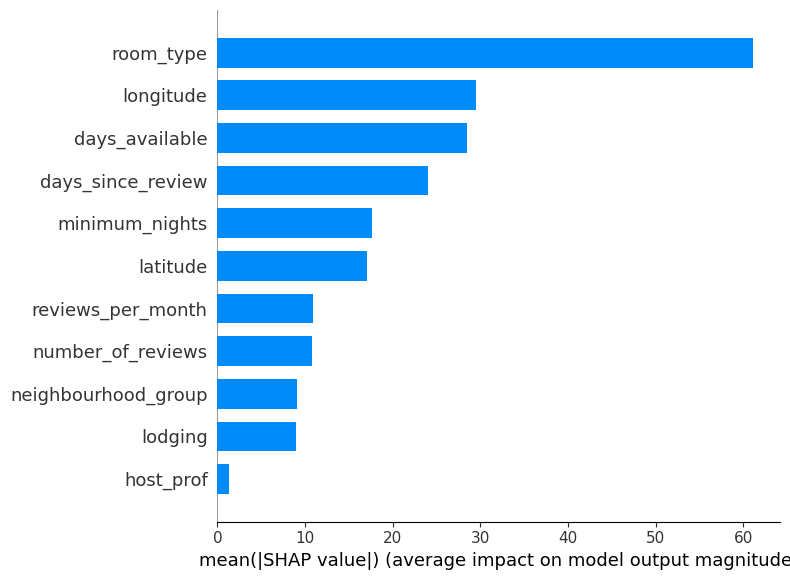

In [45]:
# Resumen gráfico de barras
shap.summary_plot(shap_vals, X_val, plot_type="bar")

## 2.2. Selección de característica según los 3 métodos

In [46]:
df_importances = (
    df_rf.drop(columns="rf_importance_acum")
    .merge(df_perm, on='feature', how='outer')
    .merge(df_shap, on='feature', how='outer')
).sort_values('rf_importance', ascending=False)

#Hallamos la media para poder comparar
df_importances['importancia_promedio'] = df_importances[['rf_importance', 'perm', 'shap']].mean(axis=1)
df_importances.sort_values('importancia_promedio', ascending=False)

,feature,rf_importance,perm,shap,importancia_promedio
5,longitude,25.027879,40.694110,13.486182,26.402724
10,room_type,6.154381,37.614902,27.909315,23.892866
1,days_since_review,13.214814,31.782088,10.954370,18.650424
9,reviews_per_month,3.875955,38.053599,4.994796,15.641450
3,latitude,21.736263,16.033156,7.768779,15.179399
0,days_available,10.119010,11.981469,12.984192,11.694890
6,minimum_nights,8.674605,16.453186,8.052878,11.060223
4,lodging,5.883608,15.791780,4.117388,8.597592
8,number_of_reviews,3.471188,10.191409,4.947764,6.203454
7,neighbourhood_group,1.124472,11.562212,4.171699,5.619461


In [47]:
#Filtrado
df_filt = df_importances[(df_importances['rf_importance']>=1)&(df_importances['perm']>=1)&(df_importances['shap']>=1)]
df_filt

,feature,rf_importance,perm,shap,importancia_promedio
5,longitude,25.027879,40.694110,13.486182,26.402724
3,latitude,21.736263,16.033156,7.768779,15.179399
1,days_since_review,13.214814,31.782088,10.954370,18.650424
0,days_available,10.119010,11.981469,12.984192,11.694890
6,minimum_nights,8.674605,16.453186,8.052878,11.060223
10,room_type,6.154381,37.614902,27.909315,23.892866
4,lodging,5.883608,15.791780,4.117388,8.597592
9,reviews_per_month,3.875955,38.053599,4.994796,15.641450
8,number_of_reviews,3.471188,10.191409,4.947764,6.203454
7,neighbourhood_group,1.124472,11.562212,4.171699,5.619461


## 2.3. Comprobación vif y correlaciones

El VIF (variance inflation factor) cuantifica la intensidad de la multicolinealidad en un análisis de regresión normal de mínimos cuadrados.

- **Fórmula**: $\displaystyle \mathrm {FIV_{i}} ={\frac {1}{1-R_{i}^{2}}}$
    - donde R2i es el coeficiente de determinación de la ecuación de regresión del primer paso, con $\displaystyle X_{i}$ en el lado izquierdo y el resto de variables predictivas en el derecho.

In [94]:
# VIF
## Variable Xi: añdimos cte. para no sumir que regresión pasa por  (0,0)
x_vif=add_constant(X_train[df_filt["feature"].tolist()].drop(columns="days_since_review"))#Seleccionamos features de X_train menos days (NaN)

## Cálculo: x_vif.values (array con los datos), i valor de la columna que asuma Yi
vif = pd.Series([variance_inflation_factor(x_vif.values, i) for i in range(x_vif.shape[1])], index=x_vif.columns).drop(index="const")
vif

longitude              1.903804
latitude               1.086301
days_available         1.142358
minimum_nights         1.057050
room_type              1.050665
lodging                1.103813
reviews_per_month      1.568498
number_of_reviews      1.549422
neighbourhood_group    1.904410
dtype: float64

Análisis:

- VIF <= 1: Ausencia de multicolinealidad. El predictor no está correlacionado con otros predictores, por lo que no infla el error típico ni afecta a la estabilidad del modelo.

- VIF entre 1 y 5: Multicolinealidad moderada. Existe cierta correlación con otros predictores, pero no suele ser grave.

- VIF > 5: Riesgo multicolinealidad. El error típico del predictor puede estar notablemente inflado, lo que puede hacer que su coeficiente sea menos fiable. Considera la posibilidad de tomar medidas para reducir la multicolinealidad, como eliminar o combinar los predictores correlacionados.

- VIF > 10: Multicolinealidad grave. El error típico del predictor está muy inflado y la estimación de su coeficiente es probablemente inestable. Suelen ser necesarias acciones correctoras, como eliminar el predictor o utilizar técnicas de regularización.

In [95]:
vif[vif>5]

Series([], dtype: float64)

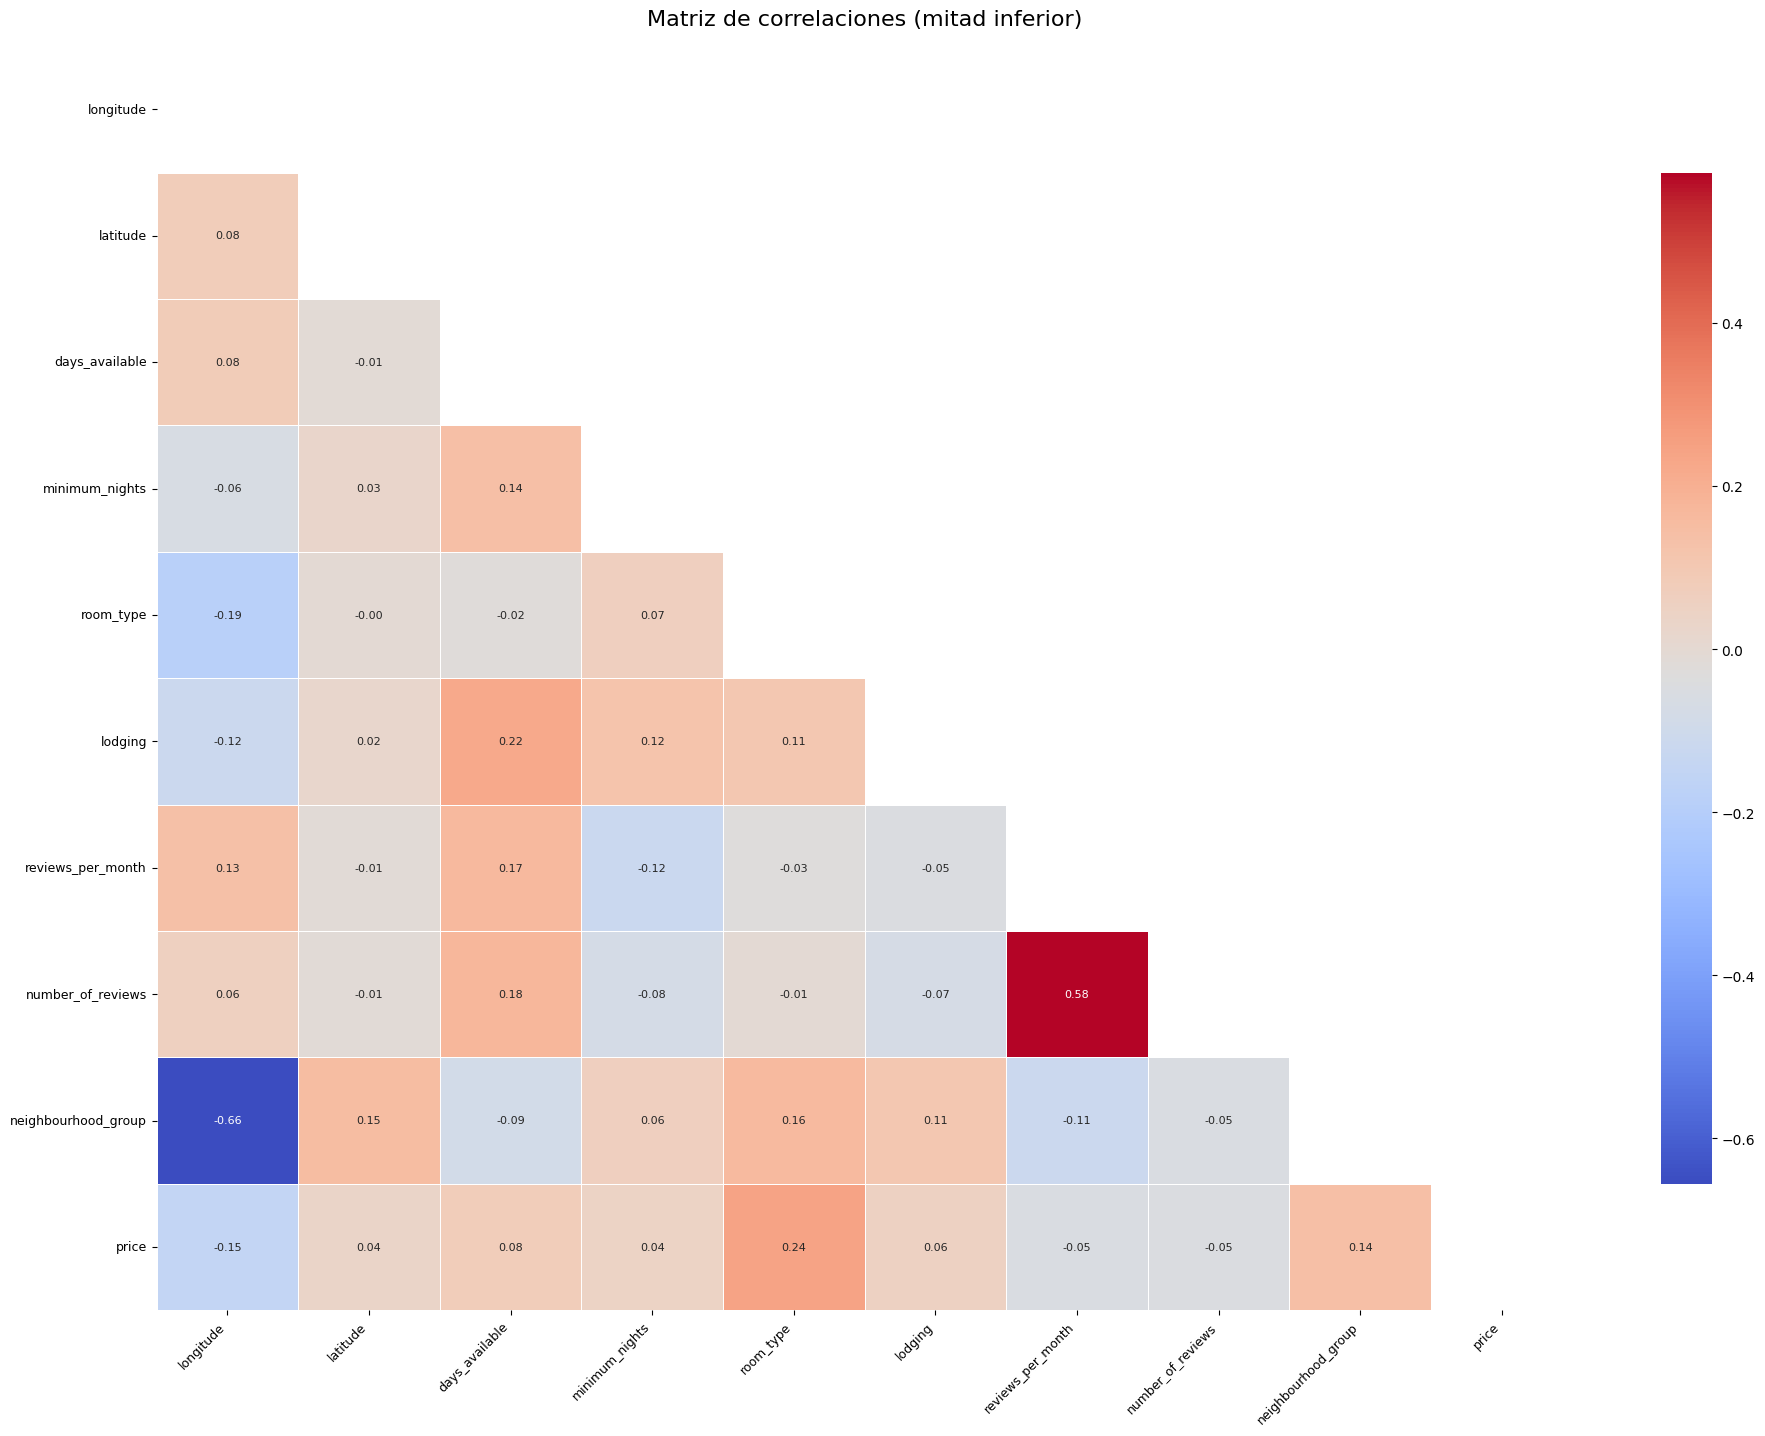

In [99]:
#Análisis de correlaciones entre regresores
x_vif.drop(columns="const", axis=1, inplace=True)
x_vif['price'] = y_train
corr = x_vif.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

#Mapa de correlaciones
plt.figure(figsize=(20, 15))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

Tras analizar el VIF, es importante verificar el análisis con la **matriz de correlaciones**. De esta forma si se observa un valor por encima de +-0.6, hay que realizar validacción cruzada para ver si esas variables se solapan o no

En nuestro caso los valores de la correlación muestran una imporante relación en el ``neighbour_hood`` y la ``longitude``.


## 2.4. Cross_validation

En primer lugar, el hecho de tener una distribución asimétrica a la izquierda y con un número elevado de outliers nos motiva a logaritmizar la variable para suavizar dicha distribución y  reducir el error de las predicciones

<Axes: ylabel='price'>

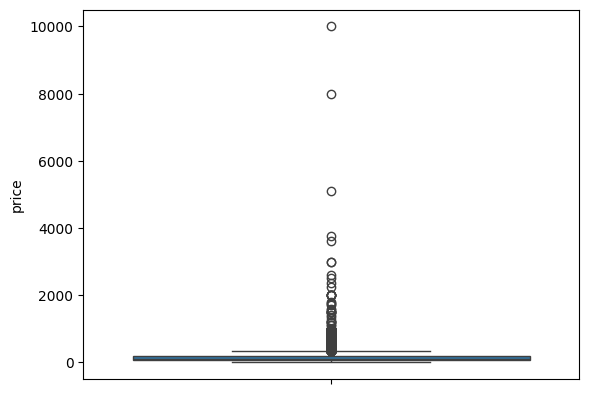

In [ ]:
sns.boxplot(y_test)

In [ ]:
# Versión 1: todas las características
cv_results1 = cross_val_score(RandomForestRegressor(random_state=42,n_jobs=-1), X_train[features], np.log(y_train+1), cv=4, scoring='neg_mean_absolute_percentage_error')

In [ ]:
print(f"Error: {cv_results1.mean()} %")

Error: -4216717615280.4424 %


In [ ]:
# Versión 2: todas las características
cv_results2 = cross_val_score(RandomForestRegressor(random_state=42,n_jobs=-1), X_train[features].drop(['neighbourhood','number_of_reviews'],axis=1), y_train, cv=3, scoring='neg_mean_absolute_percentage_error')

In [ ]:
cv_results2.mean()

### Relación 1

### Relación 2

In [ ]:
sns.boxplot(y_train)

#### Ajustamos la base de datos para desechar los outliers

In [ ]:
plt.hist(y_train, bins="auto") #[y_train<y_train.quantile(0.99)]
plt.plot()

In [ ]:
y_train.describe()

In [ ]:
df=df[(df["price"]>10)&(df['price'] <= 500)]
X = df.drop('price',axis=1)
y = df['price']

In [ ]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42) #random_state establece una semilla para que la division aleatoria sea la misma

In [ ]:
# Versión 1: todas las características
cv_results1 = cross_val_score(RandomForestRegressor(random_state=42,n_jobs=-1), X_train[features], y_train, cv=4, scoring='neg_mean_absolute_percentage_error')

In [ ]:
cv_results1.mean()